# Terrain-Informed Parcel Site Plan (Tier 4 + 3DEP Topo Engine)

This notebook merges **SitePlan_with_ParcelBoundary_6** and **CottageGrove_TopoAnalysis**.
Instead of running the Tier 4 layout on the real parcel boundary alone, it now pulls a real
USGS 3DEP elevation grid *for that same parcel* and uses it to actually shape the plan:

1. **Steep-slope exclusion** -- cells where local slope exceeds a buildable threshold are
   vectorized and subtracted from the developable core, alongside the existing synthetic
   wetland/floodplain placeholders.
2. **Contour-aligned roads & buildings** -- the best-fit grading plane gives a downhill
   bearing; roads run along the contour (perpendicular to it) and buildings' long axis
   follows the roads, instead of just the parcel's bounding-box long axis. Flat sites fall
   back to the old geometric-axis behavior automatically.
3. **Terrain-seeking pond** -- the stormwater pond is anchored at the lowest DEM elevation
   actually inside the developable core, not an arbitrary corner.
4. **Real earthwork economics** -- "Grading Risk" and cost are computed from actual cut/fill
   volumes (same best-fit-plane residual method as the topo notebook) over the final
   developable footprint, in cubic yards and dollars, replacing the old acreage-only guess.

**Offline-safe:** if the live 3DEP fetch fails (no network, no coverage), the notebook falls
back to a synthetic sloped terrain surface so the rest of the pipeline still runs end-to-end
for demonstration -- set `USE_SYNTHETIC_TERRAIN = True` to force this deliberately.


In [1]:
%%capture
# Install geospatial + terrain deps (safe to re-run).
!pip install geopandas shapely matplotlib pyproj rasterio rioxarray affine py3dep seaborn

In [2]:
import json, io, os, gzip, zipfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon, MultiPolygon, Point, box, LineString, shape as shp_shape
from shapely.affinity import translate, rotate as shp_rotate
from shapely.ops import unary_union

SQFT_PER_ACRE = 43560

## 1. Load parcels into a GeoDataFrame
Normalize the GeoJSON features, rebuild shapely geometries from `geometry.type` /
`geometry.coordinates`, and tag the CRS as WGS84 (`EPSG:4326`).

In [4]:
# --------------------------------------------------------------------------
# DATA SOURCE + USER INPUT
# --------------------------------------------------------------------------
# Point DATA_PATH at your parcel file. A .zip is fine -- the loader below unzips it in
# memory. Set USE_SAMPLE_FIXTURE = True to run without any external file (a tiny sample).
DATA_PATH          = "C:/Users/neeli/OneDrive/Documents/Heyday/il_kendall.geojson.zip"
PROJECTED_CRS      = "EPSG:3435"        # NAD83 / Illinois East (ftUS) -- Kendall County, IL
ADDRESS             = "12300 River Rd"  # <-- user-defined address (set to None to be prompted)
USE_SAMPLE_FIXTURE  = False              # True -> build & use a small local sample

if not USE_SAMPLE_FIXTURE:
    try:
        from google.colab import drive
        drive.mount("/content/drive/")
    except Exception as e:
        print(f"(Not mounting Drive: {e}) -- make sure DATA_PATH points to a local file.")

if USE_SAMPLE_FIXTURE:
    DATA_PATH = "il_kendall_SAMPLE.json"
    cx, cy = -88.4300, 41.5900          # ~Kendall County, IL
    dlon, dlat = 0.0037, 0.00275
    ring = [[cx-dlon, cy-dlat], [cx+dlon, cy-dlat*0.9], [cx+dlon*1.1, cy+dlat*0.6],
            [cx+dlon*0.2, cy+dlat], [cx-dlon*0.9, cy+dlat*0.7], [cx-dlon, cy-dlat]]
    sample = {"type": "FeatureCollection", "features": [{
        "type": "Feature", "id": "22366",
        "properties": {"geoid": "17093", "parcelnumb": "03-18-430-001",
                       "original_address.address": "7495 Rose Hill Ct",
                       "original_address.scity": "Yorkville", "original_address.szip": "60560"},
        "geometry": {"type": "Polygon", "coordinates": [ring]}}]}
    with open(DATA_PATH, "w", encoding="utf-8") as f:
        json.dump(sample, f)
    print("Wrote sample fixture ->", DATA_PATH)

(Not mounting Drive: No module named 'google') -- make sure DATA_PATH points to a local file.


In [5]:
def load_geojson(path, verbose=True):
    '''Robustly load a (Geo)JSON file whose container/encoding is unknown.

    Handles: a folder path (e.g. an extracted-zip folder), .zip archives,
    gzip, byte-order marks, and an encoding cascade. latin-1 is a *total*
    decoder (never raises).
    '''
    if os.path.isdir(path):
        found = [os.path.join(r, fn)
                 for r, _, files in os.walk(path)
                 for fn in files if fn.lower().endswith((".geojson", ".json"))]
        if not found:
            raise FileNotFoundError(f"'{path}' is a folder with no .geojson/.json file inside.")
        path = max(found, key=os.path.getsize)
        if verbose: print(f"Path was a folder; using file: {path}")

    try:
        with open(path, "rb") as fh:
            raw = fh.read()
    except PermissionError as e:
        raise PermissionError(
            f"Permission denied opening '{path}'. Likely causes on Windows/OneDrive: "
            f"(1) the path is a folder, not a file; "
            f"(2) the file is open in another program (close it); "
            f"(3) OneDrive Files On-Demand -- right-click the file and choose "
            f"'Always keep on this device' to download it; or "
            f"(4) point DATA_PATH at the .zip and let this loader unzip it in memory. "
            f"Original error: {e}"
        ) from e

    if raw[:4] == b"PK\x03\x04":
        with zipfile.ZipFile(io.BytesIO(raw)) as zf:
            names = zf.namelist()
            members = [n for n in names if n.lower().endswith((".geojson", ".json"))] or names
            member = max(members, key=lambda n: zf.getinfo(n).file_size)
            if verbose: print(f"Detected ZIP; reading member: {member}")
            raw = zf.read(member)

    if raw[:2] == b"\x1f\x8b":
        raw = gzip.decompress(raw)
        if verbose: print("Detected gzip; decompressed.")

    for bom, enc in ((b"\xef\xbb\xbf", "utf-8-sig"),
                     (b"\xff\xfe", "utf-16"),
                     (b"\xfe\xff", "utf-16")):
        if raw.startswith(bom):
            if verbose: print(f"Detected BOM -> {enc}")
            return json.loads(raw.decode(enc))

    last_err = None
    for enc in ("utf-8", "utf-16", "cp1252", "latin-1"):
        try:
            obj = json.loads(raw.decode(enc))
            if verbose: print(f"Loaded '{path}' using encoding: {enc}")
            return obj
        except (UnicodeDecodeError, json.JSONDecodeError) as e:
            last_err = e

    try:
        obj = json.loads(raw.decode("utf-8", errors="replace"))
        if verbose: print("Loaded using utf-8 with errors='replace' (some chars dropped).")
        return obj
    except json.JSONDecodeError:
        raise ValueError(
            f"Could not parse '{path}' as JSON with any encoding. "
            f"Last error: {last_err}. First 32 bytes (hex): {raw[:32].hex(' ')}"
        )

json_data = load_geojson(DATA_PATH)
df = pd.json_normalize(json_data["features"])

def create_geometry(row):
    geom_type = row["geometry.type"]
    coords = row["geometry.coordinates"]
    if geom_type == "Polygon":
        try:
            return Polygon(coords[0], holes=coords[1:]) if len(coords) > 1 else Polygon(coords[0])
        except Exception as e:
            print(f"Error creating Polygon: {e}")
            return None
    elif geom_type == "MultiPolygon":
        try:
            polygons = [Polygon(pc[0], holes=pc[1:]) if len(pc) > 1 else Polygon(pc[0]) for pc in coords]
            return MultiPolygon(polygons)
        except Exception as e:
            print(f"Error creating MultiPolygon: {e}")
            return None
    return None

df["geometry"] = df.apply(create_geometry, axis=1)
gdf = geopandas.GeoDataFrame(df.dropna(subset=["geometry"]), geometry="geometry", crs="EPSG:4326")
print(f"Loaded {len(gdf):,} parcels | CRS = {gdf.crs}")

Detected ZIP; reading member: il_kendall.json
Loaded 'C:/Users/neeli/OneDrive/Documents/Heyday/il_kendall.geojson.zip' using encoding: utf-8
Loaded 58,368 parcels | CRS = EPSG:4326


## 2. Select the parcel by address
Case-insensitive substring match on `properties.original_address.address`, then plot the raw
boundary in lon/lat to confirm the right parcel.

Found 1 parcel(s) matching '12300 River Rd'. Using the first match.


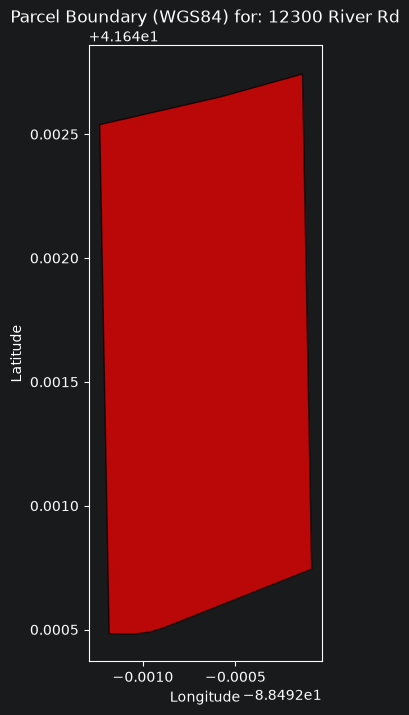

In [6]:
ADDR_COL = "properties.original_address.address"

if ADDRESS is None:
    ADDRESS = input("Enter the address of the parcel to display: ")

matching_parcels = gdf[gdf[ADDR_COL].str.contains(ADDRESS, case=False, na=False)]

if matching_parcels.empty:
    raise ValueError(f"No parcel found for '{ADDRESS}'. Try a different address or partial address.")

print(f"Found {len(matching_parcels)} parcel(s) matching '{ADDRESS}'. Using the first match.")
parcel_wgs84 = matching_parcels.iloc[[0]]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
parcel_wgs84.plot(ax=ax, color="red", edgecolor="black", alpha=0.7)
ax.set_title(f"Parcel Boundary (WGS84) for: {ADDRESS}")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

## 3. Reproject to feet
Project the matched parcel to **feet** (`PROJECTED_CRS`), collapse any MultiPolygon to its
largest ring, recenter the centroid to the origin, and derive `gross_acres` from the real area.

In [7]:
def largest_polygon(geom):
    '''Return the largest single Polygon (handles MultiPolygon parcels).'''
    if geom is None or geom.is_empty:
        return geom
    if geom.geom_type == "MultiPolygon":
        return max(geom.geoms, key=lambda g: g.area)
    return geom

parcel_ft    = parcel_wgs84.to_crs(PROJECTED_CRS)
site_geom_ft = largest_polygon(parcel_ft.geometry.iloc[0])

_cx, _cy = site_geom_ft.centroid.x, site_geom_ft.centroid.y
PARCEL_POLYGON = translate(site_geom_ft, xoff=-_cx, yoff=-_cy)   # centroid -> (0, 0)

parcel_acres = PARCEL_POLYGON.area / SQFT_PER_ACRE
_minx, _miny, _maxx, _maxy = PARCEL_POLYGON.bounds
print(f"Reprojected to {PROJECTED_CRS}")
print(f"Parcel area   : {parcel_acres:.2f} acres")
print(f"Extent (ft)   : {(_maxx-_minx):.0f} wide x {(_maxy-_miny):.0f} deep")
print(f"Original centroid (State Plane ft): ({_cx:.0f}, {_cy:.0f})")

Reprojected to EPSG:3435
Parcel area   : 5.15 acres
Extent (ft)   : 312 wide x 823 deep
Original centroid (State Plane ft): (940699, 1812037)


## 4. Terrain data acquisition (NEW)
Fetch a real USGS 3DEP elevation grid covering the *matched parcel's own footprint* (padded
by a small buffer), reprojected directly into the site plan's feet-based CRS so every pixel
lines up with `PARCEL_POLYGON`. This replaces the old topo notebook's hardcoded bounding box
with the address-driven parcel from Section 2-3.

If the live fetch isn't available (no network, no 3DEP coverage), a synthetic sloped surface
is generated instead, so the rest of the notebook still runs end-to-end.

In [8]:
TERRAIN_RESOLUTION_M   = 3      # 3DEP grid resolution in meters (1m for tiny sites, 3-10m for speed)
TERRAIN_BUFFER_FT      = 100    # pad past the parcel edge so edge buffers/grading aren't pixel-starved
USE_SYNTHETIC_TERRAIN  = False  # True -> force the offline synthetic DEM fallback

# Bounding box for the DEM pull: parcel bounds (WGS84) padded by ~TERRAIN_BUFFER_FT
_minx_ll, _miny_ll, _maxx_ll, _maxy_ll = parcel_wgs84.total_bounds
_pad_deg = TERRAIN_BUFFER_FT / 364000.0   # rough ft -> deg at mid-latitudes
dem_bbox_wgs84 = box(_minx_ll - _pad_deg, _miny_ll - _pad_deg, _maxx_ll + _pad_deg, _maxy_ll + _pad_deg)

def fetch_synthetic_dem(bounds, resolution_ft=10, slope_pct=3.0, aspect_deg=225, noise_std=0.4, seed=0):
    '''Planar grade + noise, standing in for a real DEM when 3DEP is unavailable. Returns
    (elevation grid in ft, cellsize in ft, (minx, miny, maxx, maxy) in ft) already in the
    site plan's recentered coordinate space.'''
    minx, miny, maxx, maxy = bounds
    nx = max(20, int((maxx - minx) / resolution_ft))
    ny = max(20, int((maxy - miny) / resolution_ft))
    x = np.linspace(minx, maxx, nx)
    y = np.linspace(miny, maxy, ny)
    X, Y = np.meshgrid(x, y)
    rad = np.deg2rad(aspect_deg)
    grade = slope_pct / 100.0
    Z = 700 + grade * (X * np.cos(rad) + Y * np.sin(rad))
    rng = np.random.default_rng(seed)
    Z += rng.normal(0, noise_std, Z.shape)
    return Z[::-1, :], resolution_ft, bounds   # flip so row 0 = north/top, matching raster convention

dem_ft, cellsize_ft, dem_bounds_ft = None, None, None

if not USE_SYNTHETIC_TERRAIN:
    try:
        import py3dep, rasterio, rioxarray
        print("Fetching USGS 3DEP terrain for the parcel footprint...")
        terrain_grid = py3dep.get_map(geometry=dem_bbox_wgs84, resolution=TERRAIN_RESOLUTION_M,
                                       crs="epsg:4326", layers="DEM")
        terrain_ft = terrain_grid.rio.reproject(PROJECTED_CRS)   # align pixels to the feet-based site CRS
        terrain_ft.rio.to_raster("parcel_3dep_dem_ft.tif")

        raw = terrain_ft.values.squeeze().astype(float)
        nodata = terrain_ft.rio.nodata
        if nodata is not None:
            raw = np.where(raw == nodata, np.nan, raw)
        dem_ft = raw * 3.28084   # 3DEP DEM values are meters -> feet, to match everything else here

        t = terrain_ft.rio.transform()
        cellsize_ft = abs(t.a)
        b = terrain_ft.rio.bounds()
        dem_bounds_ft = (b[0] - _cx, b[1] - _cy, b[2] - _cx, b[3] - _cy)   # recenter like PARCEL_POLYGON
        print(f"Fetched {dem_ft.shape[1]}x{dem_ft.shape[0]} DEM grid @ ~{cellsize_ft:.1f} ft/cell")
    except Exception as e:
        print(f"3DEP fetch unavailable ({e}); falling back to a synthetic terrain surface.")
        USE_SYNTHETIC_TERRAIN = True

if USE_SYNTHETIC_TERRAIN:
    minx, miny, maxx, maxy = PARCEL_POLYGON.bounds
    pad = TERRAIN_BUFFER_FT
    dem_ft, cellsize_ft, dem_bounds_ft = fetch_synthetic_dem(
        (minx - pad, miny - pad, maxx + pad, maxy + pad), resolution_ft=10)
    print(f"Using synthetic DEM: {dem_ft.shape[1]}x{dem_ft.shape[0]} grid @ {cellsize_ft:.0f} ft/cell "
          f"(no live 3DEP fetch).")

# Fill any nodata gaps with the local mean so downstream slope math doesn't choke on NaNs.
if np.isnan(dem_ft).any():
    dem_ft = np.where(np.isnan(dem_ft), np.nanmean(dem_ft), dem_ft)

rows, cols = dem_ft.shape
minx, miny, maxx, maxy = dem_bounds_ft

Fetching USGS 3DEP terrain for the parcel footprint...
3DEP fetch unavailable (Cannot connect to host elevation.nationalmap.gov:443 ssl:default [Could not contact DNS servers]); falling back to a synthetic terrain surface.
Using synthetic DEM: 51x102 grid @ 10 ft/cell (no live 3DEP fetch).


## 5. Terrain analysis engine
Same methodology as the topo notebook -- mean elevation, a best-fit grading plane by least
squares, and the residual surface -- but now on the parcel-scoped DEM above, plus a local
(cell-to-cell) slope grid used to flag unbuildable ground.

Mean elevation        : 700.0 ft
Best-fit grading plane: 3.00% slope, downhill bearing 45 deg
Local slope (site)    : 4.61% avg, 17.00% max


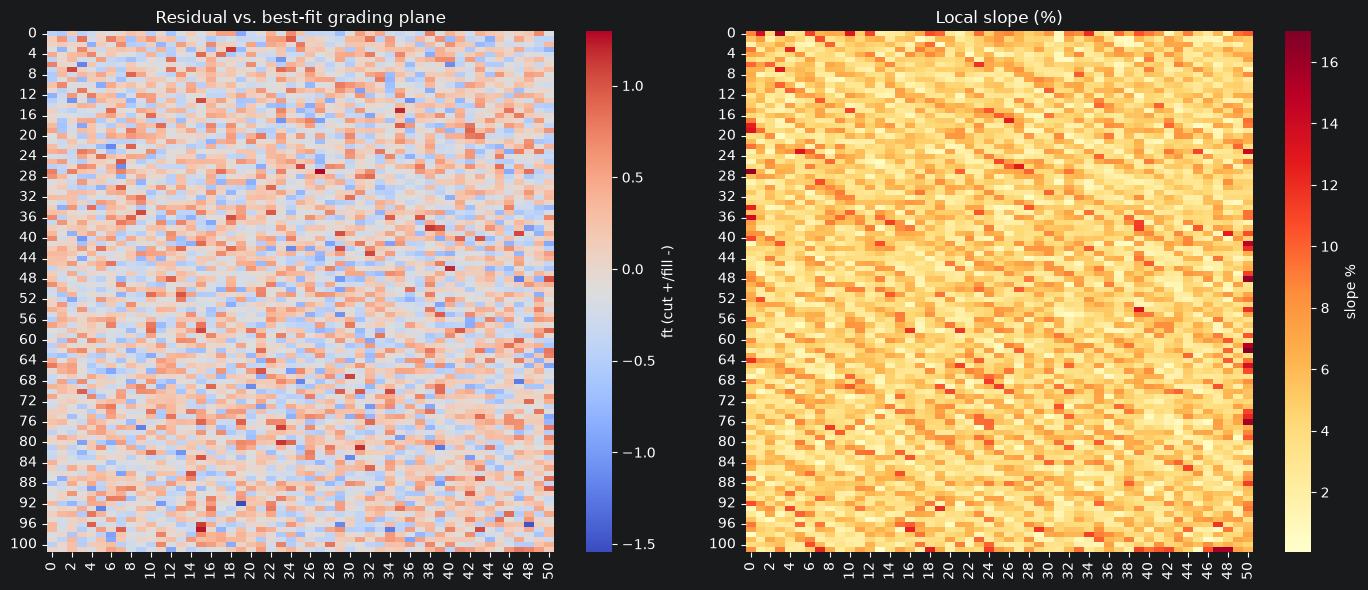

In [9]:
xs = np.linspace(minx, maxx, cols)
ys = np.linspace(maxy, miny, rows)   # row 0 = top = maxy, matching raster convention
Xg, Yg = np.meshgrid(xs, ys)

mean_elevation_ft = float(np.nanmean(dem_ft))

# Best-fit grading plane: z = A*x + B*y + C  (least squares, same technique as the topo notebook)
A_mat = np.c_[Xg.ravel(), Yg.ravel(), np.ones(Xg.size)]
coeffs, *_ = np.linalg.lstsq(A_mat, dem_ft.ravel(), rcond=None)
grade_x, grade_y, grade_c = coeffs
fitted_plane_ft = (grade_x * Xg + grade_y * Yg + grade_c)

residual_from_plane_ft = dem_ft - fitted_plane_ft     # +cut / -fill vs. one balanced grading plane
residual_from_mean_ft  = dem_ft - mean_elevation_ft

# Slope + downhill direction of the fitted plane -- feeds the orientation/pond logic below
plane_slope_pct = float(np.hypot(grade_x, grade_y) * 100)
downhill_bearing_deg = float(np.degrees(np.arctan2(-grade_y, -grade_x)) % 360)

# Local (cell-to-cell) slope from the actual DEM -- flags "too steep to build"
dzdy, dzdx = np.gradient(dem_ft, cellsize_ft)
local_slope_pct = np.hypot(dzdx, dzdy) * 100

print(f"Mean elevation        : {mean_elevation_ft:.1f} ft")
print(f"Best-fit grading plane: {plane_slope_pct:.2f}% slope, downhill bearing {downhill_bearing_deg:.0f} deg")
print(f"Local slope (site)    : {np.nanmean(local_slope_pct):.2f}% avg, {np.nanmax(local_slope_pct):.2f}% max")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(residual_from_plane_ft, cmap="coolwarm", cbar_kws={"label": "ft (cut +/fill -)"}, ax=axes[0])
axes[0].set_title("Residual vs. best-fit grading plane")
sns.heatmap(local_slope_pct, cmap="YlOrRd", cbar_kws={"label": "slope %"}, ax=axes[1])
axes[1].set_title("Local slope (%)")
plt.tight_layout()
plt.show()

## 6. Derive terrain-informed constraints
Vectorize the steep-slope cells into a real exclusion polygon (in the same recentered feet
CRS as `PARCEL_POLYGON`), and set up a DEM sampler used to find the pond's low point.

In [10]:
MAX_BUILDABLE_SLOPE_PCT = 15.0   # above this, terrain becomes an exclusion zone

steep_mask = (local_slope_pct > MAX_BUILDABLE_SLOPE_PCT)

steep_slope_zone = None
if steep_mask.any():
    try:
        import rasterio.features
        from affine import Affine
        transform = Affine(cellsize_ft, 0, minx, 0, -cellsize_ft, maxy)
        shapes_gen = rasterio.features.shapes(steep_mask.astype(np.uint8), mask=steep_mask, transform=transform)
        steep_polys = [shp_shape(geom) for geom, val in shapes_gen if val == 1]
        if steep_polys:
            steep_slope_zone = unary_union(steep_polys).buffer(0)
    except Exception as e:
        print(f"Vectorizing the steep-slope mask failed ({e}); continuing without a slope exclusion layer.")

if steep_slope_zone is not None and not steep_slope_zone.is_empty:
    print(f"Steep-slope (>{MAX_BUILDABLE_SLOPE_PCT:.0f}%) exclusion zone: {steep_mask.mean()*100:.1f}% of the DEM footprint")
else:
    print(f"No slopes exceed the {MAX_BUILDABLE_SLOPE_PCT:.0f}% buildable threshold -- terrain isn't a binding constraint here.")

def dem_value_at(px, py):
    '''Nearest-neighbor DEM lookup in the recentered feet coordinate space.'''
    col = int(np.clip((px - minx) / cellsize_ft, 0, cols - 1))
    row = int(np.clip((maxy - py) / cellsize_ft, 0, rows - 1))
    return dem_ft[row, col]

Steep-slope (>15%) exclusion zone: 0.1% of the DEM footprint


## 7. Tier 4 site plan on the real parcel (terrain-informed)
Same pipeline shape as before (buffer, constraints, pond, roads, buildings, density), refined
so the terrain data from Sections 4-6 actually drives the layout:

1. **`simulate_constraints`** now differences the real steep-slope zone out of the developable
   core, in addition to the synthetic wetland/floodplain placeholders.
2. **`terrain_orientation_bearing` / `generate_roads` / `place_buildings`** align to the
   contour (perpendicular to the fitted plane's downhill bearing) when the site is steep
   enough for it to matter; dead-flat parcels fall back to the old bounding-box long axis.
3. **`pick_pond_site`** samples the DEM inside the developable core and anchors the pond at
   the lowest point found, instead of an arbitrary corner.
4. **`real_cut_fill` + `grading_risk`** replace the acreage-only heuristic with actual
   cubic-yard cut/fill (same residual-vs-plane method as the topo notebook) scoped to the
   final net developable footprint, plus a dollar estimate.

In [11]:
CONFIG = {
    "use_parcel_boundary": True,
    "projected_crs": PROJECTED_CRS,
    "gross_acres": round(parcel_acres, 2),
    "site_address": ADDRESS,
    "site_center_x_ft": 0, "site_center_y_ft": 0,
    "frontage_ft": None, "depth_ft": None, "aspect_ratio": 1.4,

    "constraints_enabled": True,
    "wetland_pct": 0.06, "floodplain_pct": 0.02,
    "edge_buffer_ft": 40, "wetland_buffer_ft": 5,

    # ---- terrain-driven constraints ----
    "use_slope_exclusion": True,
    "max_buildable_slope_pct": MAX_BUILDABLE_SLOPE_PCT,

    "pond_pct": 0.10,
    "road_width_ft": 26, "road_spacing_ft": 180,
    "building_width_ft": 80, "building_depth_ft": 42,
    "building_spacing_ft": 12, "rear_separation_ft": 30,
    "units_per_building": 6,
    "auto_orient_buildings": True,
    "grid_search_steps": 4,

    # ---- terrain-driven orientation ----
    "orient_to_terrain": True,
    "terrain_orientation_min_slope_pct": 2.0,  # below this the grade is ~flat -> geometric long axis

    "target_density_du_ac": 10,
    "cut_cost_per_cy": 9.0,     # $/cy, typical earthwork cut
    "fill_cost_per_cy": 12.0,   # $/cy, typical earthwork fill (import + compaction)
    "plot": True,
}

# ------------------------------------------------------------
def acreage_to_dimensions(acres, aspect_ratio=1.4):
    area_sqft = acres * SQFT_PER_ACRE
    width = np.sqrt(area_sqft * aspect_ratio)
    height = area_sqft / width
    return width, height

def build_site_polygon(config, parcel_polygon=None):
    if config.get("use_parcel_boundary") and parcel_polygon is not None:
        return largest_polygon(parcel_polygon)
    if config["frontage_ft"] and config["depth_ft"]:
        width, height = config["frontage_ft"], config["depth_ft"]
    else:
        width, height = acreage_to_dimensions(config["gross_acres"], config["aspect_ratio"])
    cx, cy = config["site_center_x_ft"], config["site_center_y_ft"]
    return box(cx - width/2, cy - height/2, cx + width/2, cy + height/2)

def create_developable_area(site_poly, config):
    return largest_polygon(site_poly.buffer(-config["edge_buffer_ft"]))

def simulate_constraints(dev_poly, config, slope_zone=None):
    '''Adds the real DEM-derived steep-slope exclusion to the synthetic wetland/floodplain
    placeholders, so terrain doesn't just show up in the risk score -- it actually removes
    unbuildable ground from the developable core.'''
    if not config.get("constraints_enabled", True):
        return dev_poly, None, None, None
    minx_, miny_, maxx_, maxy_ = dev_poly.bounds
    area = dev_poly.area
    wetland = Point(minx_ + (maxx_-minx_)*0.18, miny_ + (maxy_-miny_)*0.85).buffer(
              np.sqrt(area*config["wetland_pct"]/np.pi))
    flood = Point(minx_ + (maxx_-minx_)*0.85, miny_ + (maxy_-miny_)*0.15).buffer(
            np.sqrt(area*config["floodplain_pct"]/np.pi))
    exclusions = [wetland.buffer(config["wetland_buffer_ft"]), flood]

    slope_excl = None
    if config.get("use_slope_exclusion") and slope_zone is not None and not slope_zone.is_empty:
        candidate = slope_zone.intersection(dev_poly)
        if not candidate.is_empty:
            slope_excl = candidate
            exclusions.append(slope_excl)

    net = dev_poly.difference(unary_union(exclusions))
    return largest_polygon(net), wetland, flood, slope_excl

def pick_pond_site(net_poly, config, dem_sampler=None):
    '''Anchors the stormwater pond at the lowest DEM elevation found inside the developable
    core (falls back to the low-corner heuristic without a DEM sample), since gravity-fed
    drainage to the real low point minimizes pumping and grading cost.'''
    radius = np.sqrt(net_poly.area * config["pond_pct"] / np.pi)
    minx_, miny_, maxx_, maxy_ = net_poly.bounds
    if dem_sampler is not None and maxx_ - radius > minx_ + radius and maxy_ - radius > miny_ + radius:
        gx = np.linspace(minx_ + radius, maxx_ - radius, 12)
        gy = np.linspace(miny_ + radius, maxy_ - radius, 12)
        best_pt, best_z = None, np.inf
        for px in gx:
            for py in gy:
                pt = Point(px, py)
                if net_poly.contains(pt):
                    z = dem_sampler(px, py)
                    if z < best_z:
                        best_z, best_pt = z, pt
        if best_pt is not None:
            return best_pt.buffer(radius)
    return Point(minx_ + radius*0.7, miny_ + radius*0.7).buffer(radius)   # fallback

def terrain_orientation_bearing(config, plane_slope_pct, downhill_bearing_deg):
    '''Roads run along the contour (perpendicular to the downhill direction) to minimize
    cross-slope cut/fill; buildings' long axis follows the same line. Only kicks in once the
    fitted grading plane is steep enough to matter.'''
    if config.get("orient_to_terrain") and plane_slope_pct >= config.get("terrain_orientation_min_slope_pct", 2.0):
        return (downhill_bearing_deg + 90) % 180
    return None

def _long_axis_is_y(poly):
    minx_, miny_, maxx_, maxy_ = poly.bounds
    return (maxy_ - miny_) >= (maxx_ - minx_)

def generate_roads(net_poly, pond, config, orientation_deg=None):
    '''Cross-streets align to the terrain contour when orientation_deg is supplied (real
    grade evidence), otherwise fall back to perpendicular-to-long-axis.'''
    minx_, miny_, maxx_, maxy_ = net_poly.bounds
    spacing, width = config["road_spacing_ft"], config["road_width_ft"]

    if orientation_deg is not None:
        cx_, cy_ = (minx_+maxx_)/2, (miny_+maxy_)/2
        diag = np.hypot(maxx_-minx_, maxy_-miny_)
        theta = np.deg2rad(orientation_deg)
        dirx, diry = np.cos(theta), np.sin(theta)
        nx_, ny_ = -diry, dirx
        roads = []
        for s in np.arange(-diag/2, diag/2, spacing):
            ox, oy = cx_ + nx_*s, cy_ + ny_*s
            seg = LineString([(ox - dirx*diag, oy - diry*diag), (ox + dirx*diag, oy + diry*diag)])
            r = largest_polygon(net_poly.intersection(seg.buffer(width/2, cap_style=3, join_style=3)))
            if (not r.is_empty) and (not r.intersects(pond)) and r.area > width*40:
                roads.append(r)
        return roads

    if _long_axis_is_y(net_poly):
        coords = np.arange(miny_ + spacing, maxy_ - spacing/2, spacing)
        make = lambda c: LineString([(minx_, c), (maxx_, c)])
    else:
        coords = np.arange(minx_ + spacing, maxx_ - spacing/2, spacing)
        make = lambda c: LineString([(c, miny_), (c, maxy_)])
    roads = []
    for c in coords:
        seg = make(c).buffer(width/2, cap_style=3, join_style=3)
        r = largest_polygon(net_poly.intersection(seg))
        if (not r.is_empty) and (not r.intersects(pond)) and r.area > width*40:
            roads.append(r)
    return roads

def place_buildings(net_poly, roads, pond, config, orientation_deg=None):
    '''When terrain gives a contour direction, buildings' long side runs parallel to it (the
    same line the roads follow) instead of just the parcel's bounding-box long axis.'''
    b_w, b_d = config["building_width_ft"], config["building_depth_ft"]
    use_terrain_axis = orientation_deg is not None
    if config.get("auto_orient_buildings", True) and not use_terrain_axis and _long_axis_is_y(net_poly):
        fw, fd = b_d, b_w
    else:
        fw, fd = b_w, b_d

    side, row_gap = config["building_spacing_ft"], config["rear_separation_ft"]
    blockers = [g for g in ([pond] + list(roads)) if g is not None]
    blocked = unary_union(blockers) if blockers else None
    steps = max(1, int(config.get("grid_search_steps", 4)))

    if not use_terrain_axis:
        minx_, miny_, maxx_, maxy_ = net_poly.bounds
        best = []
        for ox in np.linspace(0, fw + side, steps):
            for oy in np.linspace(0, fd + row_gap, steps):
                placed = []
                y = miny_ + oy + 5
                while y < maxy_ - fd:
                    x = minx_ + ox + 5
                    while x < maxx_ - fw:
                        b = box(x, y, x + fw, y + fd)
                        if net_poly.contains(b) and (blocked is None or not b.intersects(blocked)):
                            placed.append(b)
                        x += fw + side
                    y += fd + row_gap
                if len(placed) > len(best):
                    best = placed
        return best

    # Terrain-oriented placement: rotate the search grid into contour-aligned space, place
    # boxes, then rotate them back so buildings stay parallel to the terrain-aligned roads.
    theta = orientation_deg
    cx_, cy_ = net_poly.centroid.x, net_poly.centroid.y
    net_rot = shp_rotate(net_poly, -theta, origin=(cx_, cy_))
    blocked_rot = shp_rotate(blocked, -theta, origin=(cx_, cy_)) if blocked is not None else None
    rminx, rminy, rmaxx, rmaxy = net_rot.bounds

    best = []
    for ox in np.linspace(0, fw + side, steps):
        for oy in np.linspace(0, fd + row_gap, steps):
            placed = []
            y = rminy + oy + 5
            while y < rmaxy - fd:
                x = rminx + ox + 5
                while x < rmaxx - fw:
                    b = box(x, y, x + fw, y + fd)
                    if net_rot.contains(b) and (blocked_rot is None or not b.intersects(blocked_rot)):
                        placed.append(b)
                    x += fw + side
                y += fd + row_gap
            if len(placed) > len(best):
                best = placed
    return [shp_rotate(b, theta, origin=(cx_, cy_)) for b in best]

def real_cut_fill(footprint_poly, config):
    '''Cut/fill for a specific footprint, computed the same way as the topo notebook --
    residual vs. the best-fit grading plane -- scoped to the ground actually being built on,
    reported in cubic yards. Applies the same 25% swell/compaction factors as the topo
    notebook.'''
    fminx, fminy, fmaxx, fmaxy = footprint_poly.bounds
    col0 = int(np.clip((fminx - minx) / cellsize_ft, 0, cols-1))
    col1 = int(np.clip((fmaxx - minx) / cellsize_ft, 0, cols-1))
    row0 = int(np.clip((maxy - fmaxy) / cellsize_ft, 0, rows-1))
    row1 = int(np.clip((maxy - fminy) / cellsize_ft, 0, rows-1))
    if col1 <= col0 or row1 <= row0:
        return 0.0, 0.0, 0.0
    sub_residual = residual_from_plane_ft[row0:row1, col0:col1]
    cell_area_sqft = cellsize_ft ** 2
    cut_cy = float(np.sum(sub_residual[sub_residual > 0]) * cell_area_sqft / 27.0)
    fill_cy = float(np.sum(np.abs(sub_residual[sub_residual < 0])) * cell_area_sqft / 27.0)
    swell, compact = 0.25, 0.25
    net_cy = cut_cy*(1+swell) - fill_cy*(1+compact)
    return cut_cy, fill_cy, net_cy

def grading_risk(cut_cy, fill_cy, net_acres):
    '''Replaces the old acreage-only heuristic with actual earthwork intensity (cubic yards
    moved per net developable acre) -- a small-but-steep site and a large-but-flat site were
    indistinguishable under the old rule; this fixes that.'''
    intensity = (cut_cy + fill_cy) / net_acres if net_acres else 0
    if intensity < 400:   return "Low", intensity
    if intensity < 1500:  return "Moderate", intensity
    return "High", intensity


TIER 4 UNDERWRITING RESULTS (terrain-informed)
Site Address: 12300 River Rd
Gross Acres: 5.15
Net Acres: 3.08

Buildings: 7
Units: 42
Building Coverage: 10.5% of gross site

Gross Density: 8.15 du/ac
Net Density: 13.64 du/ac
Target Density: 10 du/ac  ->  82% of target achieved

Road Count: 2
Layout Orientation: terrain contour (135 deg axis)

--- Earthwork (from real 3DEP-derived terrain) ---
Cut Volume: 989 cy
Fill Volume: 1,036 cy
Net (swelled cut - compacted fill): -59 cy (import)
Earthwork Cost Estimate: $21,325
Earthwork Intensity: 657 cy/net acre
Grading Risk: Moderate


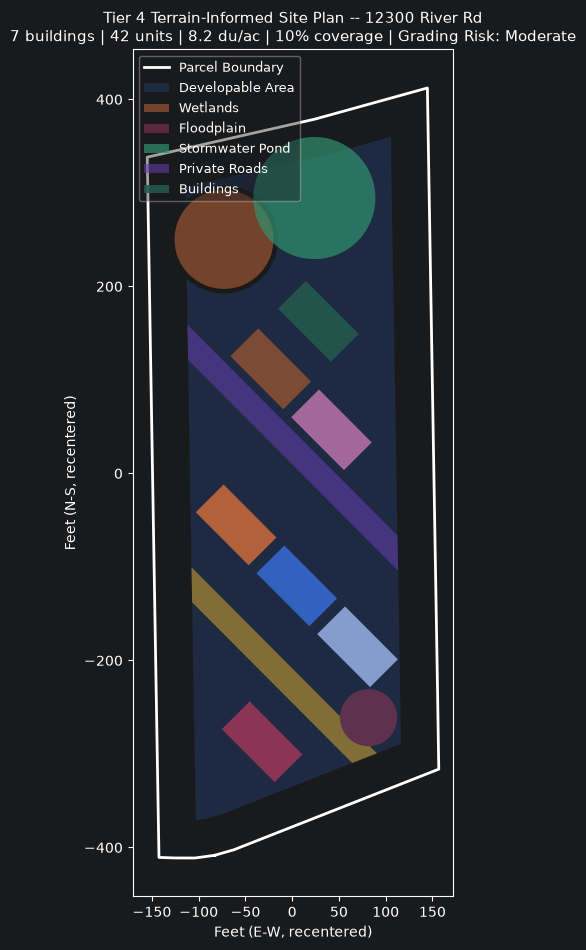

In [12]:
# ============================================================
# MAIN PIPELINE (terrain-informed)
# ============================================================
site        = build_site_polygon(CONFIG, parcel_polygon=PARCEL_POLYGON)
developable = create_developable_area(site, CONFIG)
net_area, p_wetlands, p_floodplain, p_slope_excl = simulate_constraints(
    developable, CONFIG, slope_zone=steep_slope_zone)

orientation_deg = terrain_orientation_bearing(CONFIG, plane_slope_pct, downhill_bearing_deg)

pond      = pick_pond_site(net_area, CONFIG, dem_sampler=dem_value_at)
roads     = generate_roads(net_area, pond, CONFIG, orientation_deg)
buildings = place_buildings(net_area, roads, pond, CONFIG, orientation_deg)

# ============================================================
# METRICS  (now including real, DEM-derived earthwork)
# ============================================================
gross_acres = site.area / SQFT_PER_ACRE
net_acres   = net_area.area / SQFT_PER_ACRE
unit_count  = len(buildings) * CONFIG["units_per_building"]
gross_density = unit_count / gross_acres if gross_acres else 0
net_density   = unit_count / net_acres if net_acres else 0
building_sqft = sum(b.area for b in buildings)
coverage_pct  = building_sqft / site.area * 100 if site.area else 0
target = CONFIG["target_density_du_ac"]

cut_cy, fill_cy, net_cy = real_cut_fill(net_area, CONFIG)
risk, earthwork_intensity = grading_risk(cut_cy, fill_cy, net_acres)
earthwork_cost = cut_cy*CONFIG["cut_cost_per_cy"] + fill_cy*CONFIG["fill_cost_per_cy"]

print("\n==============================")
print("TIER 4 UNDERWRITING RESULTS (terrain-informed)")
print("==============================")
print(f"Site Address: {CONFIG['site_address']}")
print(f"Gross Acres: {gross_acres:.2f}")
print(f"Net Acres: {net_acres:.2f}")
print(f"\nBuildings: {len(buildings)}")
print(f"Units: {unit_count}")
print(f"Building Coverage: {coverage_pct:.1f}% of gross site")
print(f"\nGross Density: {gross_density:.2f} du/ac")
print(f"Net Density: {net_density:.2f} du/ac")
print(f"Target Density: {target} du/ac  ->  {gross_density/target*100:.0f}% of target achieved")
print(f"\nRoad Count: {len(roads)}")
orient_note = f"terrain contour ({orientation_deg:.0f} deg axis)" if orientation_deg is not None else "geometric long axis (flat/low-slope site)"
print(f"Layout Orientation: {orient_note}")
print(f"\n--- Earthwork (from real 3DEP-derived terrain) ---")
print(f"Cut Volume: {cut_cy:,.0f} cy")
print(f"Fill Volume: {fill_cy:,.0f} cy")
print(f"Net (swelled cut - compacted fill): {net_cy:,.0f} cy {'(export)' if net_cy > 0 else '(import)'}")
print(f"Earthwork Cost Estimate: ${earthwork_cost:,.0f}")
print(f"Earthwork Intensity: {earthwork_intensity:,.0f} cy/net acre")
print(f"Grading Risk: {risk}")
print("==============================")

# ============================================================
# VISUALIZATION
# ============================================================
def _fill_geom(ax, geom, label=None, **kw):
    if geom is None or geom.is_empty:
        return
    parts = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    first = True
    for part in parts:
        gx, gy = part.exterior.xy
        ax.fill(gx, gy, label=(label if first else None), **kw)
        first = False

if CONFIG["plot"]:
    fig, ax = plt.subplots(figsize=(9, 11))
    edge = plt.rcParams.get("text.color", "black")
    bx, by = site.exterior.xy
    ax.plot(bx, by, linewidth=2, color=edge, label="Parcel Boundary")

    _fill_geom(ax, net_area,     label="Developable Area", alpha=0.2)
    _fill_geom(ax, p_wetlands,   label="Wetlands",         alpha=0.5)
    _fill_geom(ax, p_floodplain, label="Floodplain",       alpha=0.5)
    _fill_geom(ax, p_slope_excl, label=f"Steep Slope (>{CONFIG['max_buildable_slope_pct']:.0f}%)",
               alpha=0.5, color="saddlebrown")
    _fill_geom(ax, pond,         label="Stormwater Pond",  alpha=0.7)

    first_road = True
    for road_geom in roads:
        _fill_geom(ax, road_geom, label=("Private Roads" if first_road else None), alpha=0.6)
        first_road = False

    first_building = True
    for b in buildings:
        _fill_geom(ax, b, label=("Buildings" if first_building else None), alpha=0.85)
        first_building = False

    ax.set_title(f"Tier 4 Terrain-Informed Site Plan -- {CONFIG['site_address']}\n"
                 f"{len(buildings)} buildings | {unit_count} units | {gross_density:.1f} du/ac | "
                 f"{coverage_pct:.0f}% coverage | Grading Risk: {risk}", fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel("Feet (E-W, recentered)")
    ax.set_ylabel("Feet (N-S, recentered)")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.4)
    plt.show()